In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("albenft/game-of-thrones-script-all-seasons")

print("Path to dataset files:", path)

Path to dataset files: /Users/evelynchu/.cache/kagglehub/datasets/albenft/game-of-thrones-script-all-seasons/versions/1


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import os

# 文件路径
directory = "/Users/evelynchu/.cache/kagglehub/datasets/albenft/game-of-thrones-script-all-seasons/versions/1"
Game_of_Thrones_text = os.path.join(directory, "Game_of_Thrones_Script.csv")

# 读取CSV
file = pd.read_csv(Game_of_Thrones_text)

# 提取第三季第九集
episode_text = file[(file['Season'] == 'Season 3') & (file['Episode'] == 'Episode 9')]

# 提取句子列并删除空值
sentences = episode_text['Sentence'].dropna().tolist()



In [7]:
# 转为 DataFrame，列名为 text
df = pd.DataFrame({'text': sentences})

# 保存为 CSV 文件（可选 utf-8-sig，防止中文乱码）
df.to_csv("/Users/evelynchu/Desktop/GOT_S3E9_cleaned_sentences.csv", index=False, encoding='utf-8-sig')

df.head()


,text
0,Are you sure about this?
1,No.
2,It's dangerous.
3,"If we take Tywin's castle from him, the lords ..."
4,Why are you telling me?


In [8]:
pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# 读取你的英文台词 CSV
df = pd.read_csv("/Users/evelynchu/Desktop/GOT_S3E9_cleaned_sentences.csv")
texts = df['text'].dropna().tolist()

# 选择英文情感模型（DistilBERT）
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# 创建pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# 分析前100句（可换成完整 texts）
results = sentiment_pipeline(texts[:100])

# 整理成结果 DataFrame
df_result = pd.DataFrame({
    "text": texts[:100],
    "sentiment_label": [res['label'] for res in results],
    "confidence": [res['score'] for res in results]
})

# 可选：标签映射
df_result["polarity"] = df_result["sentiment_label"].map({
    "POSITIVE": "Positive",
    "NEGATIVE": "Negative"
})

# 展示结果
print(df_result.head())

# 保存结果
df_result.to_csv("/Users/evelynchu/Desktop/GOT_S3E9_sentiment_result.csv", index=False, encoding='utf-8-sig')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Device set to use mps:0


                                                text sentiment_label  \
0                           Are you sure about this?        POSITIVE   
1                                                No.        NEGATIVE   
2                                    It's dangerous.        NEGATIVE   
3  If we take Tywin's castle from him, the lords ...        NEGATIVE   
4                            Why are you telling me?        NEGATIVE   

   confidence  polarity  
0    0.997793  Positive  
1    0.997289  Negative  
2    0.997349  Negative  
3    0.978534  Negative  
4    0.997119  Negative  


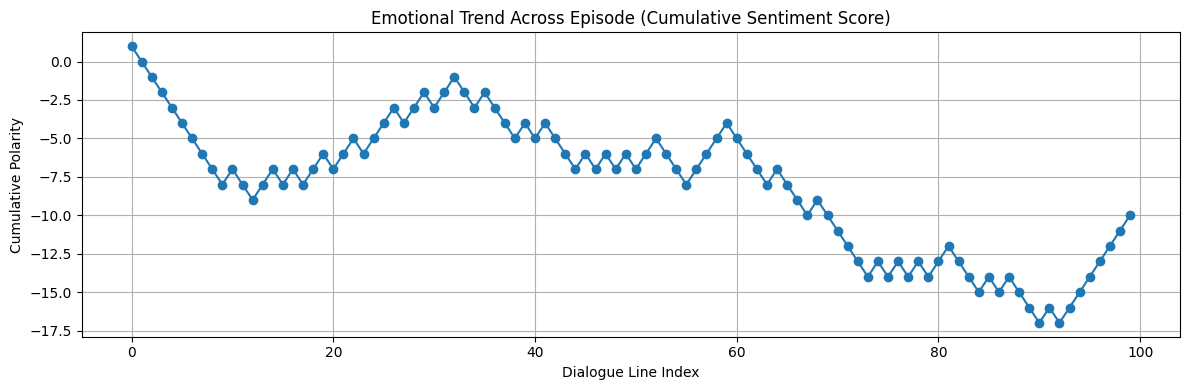

In [4]:
import matplotlib.pyplot as plt

# 把正负情绪映射为数值
df_result["polarity_score"] = df_result["sentiment_label"].apply(lambda x: 1 if x == "POSITIVE" else -1)

# 绘制累计情绪曲线
plt.figure(figsize=(12, 4))
plt.plot(df_result["polarity_score"].cumsum(), marker='o', linestyle='-')
plt.title("Emotional Trend Across Episode (Cumulative Sentiment Score)")
plt.xlabel("Dialogue Line Index")
plt.ylabel("Cumulative Polarity")
plt.grid(True)
plt.tight_layout()
plt.show()



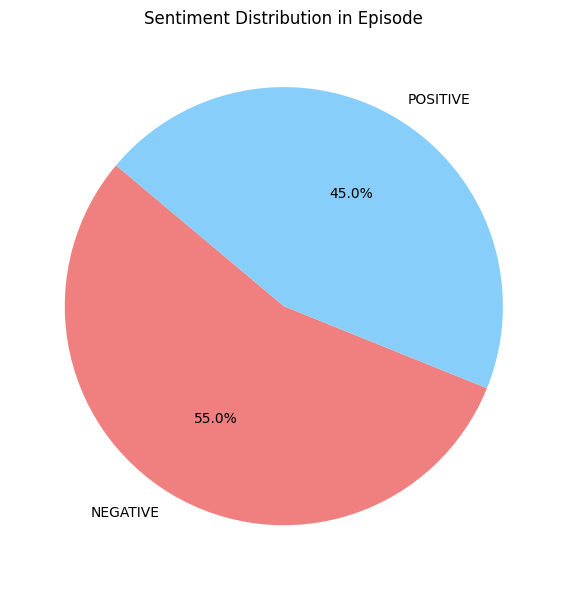

In [5]:
# 饼图展示正负情绪占比
sentiment_counts = df_result["sentiment_label"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue'])
plt.title("Sentiment Distribution in Episode")
plt.tight_layout()
plt.show()


In [6]:
# 按照情绪置信度排序，取Top 10
top_emotions = df_result.sort_values(by="confidence", ascending=False).head(10)

# 打印查看
print(top_emotions[["text", "sentiment_label", "confidence"]])


                                                 text sentiment_label  \
49                          Very good. We'll prepare.        POSITIVE   
64                                       Many thanks.        POSITIVE   
25                                         Very good.        POSITIVE   
22                                         I'm Merry.        POSITIVE   
32                                Thank you, my lord.        POSITIVE   
13  My honored guests, be welcome within my walls ...        POSITIVE   
47                                       I trust him.        POSITIVE   
14        We thank you for your hospitality, my lord.        POSITIVE   
74                                              Good.        POSITIVE   
56                                               Yes.        POSITIVE   

    confidence  
49    0.999865  
64    0.999848  
25    0.999848  
22    0.999843  
32    0.999840  
13    0.999839  
47    0.999826  
14    0.999820  
74    0.999816  
56    0.999806  


In [8]:
from music21 import converter
The_Rains_of_Castramere = converter.parse('/Users/evelynchu/Desktop/The rains of Castamere.mxl')
The_Rains_of_Castramere.show('text')

{0.0} <music21.text.TextBox '70015'>
{0.0} <music21.text.TextBox '47'>
{0.0} <music21.text.TextBox '51'>
{0.0} <music21.text.TextBox 'The rains ...'>
{0.0} <music21.text.TextBox '4401917'>
{0.0} <music21.metadata.Metadata object at 0x32fe920c0>
{0.0} <music21.stream.PartStaff P1-Staff1>
    {0.0} <music21.instrument.Piano 'P1: Piano: Acoustic Grand Piano'>
    {0.0} <music21.stream.Measure 1 offset=0.0>
        {0.0} <music21.layout.SystemLayout>
        {0.0} <music21.layout.StaffLayout distance None, staffNumber None, staffSize None, staffLines None>
        {0.0} <music21.clef.TrebleClef>
        {0.0} <music21.key.KeySignature of 1 flat>
        {0.0} <music21.stream.Voice 1>
            {0.0} <music21.note.Note F>
            {1.5} <music21.note.Note A>
            {2.0} <music21.note.Note G>
            {2.5} <music21.note.Note F>
        {0.0} <music21.stream.Voice 6>
            {2.5} <music21.note.Rest eighth>
    {3.0} <music21.stream.Measure 2 offset=3.0>
        {0.0} <musi

In [9]:
import pandas as pd
from music21 import note, chord

rain_music = []
for element in The_Rains_of_Castramere.recurse():
    if isinstance(element, note.Note):
        rain_music.append({
            'type': 'note',
            'pitch': element.pitch.midi,
            'duration': element.duration.quarterLength,
            'offset': element.offset
        })
    elif isinstance(element, chord.Chord):
        rain_music.append({
            'type': 'chord',
            'pitch': '-'.join(str(n.pitch.midi) for n in element.notes),
            'duration': element.duration.quarterLength,
            'offset': element.offset
        })

rain_music_df = pd.DataFrame(rain_music)

print(rain_music_df.head())

   type  pitch  duration  offset
0  note     77       1.5     0.0
1  note     81       0.5     1.5
2  note     79       0.5     2.0
3  note     77       0.5     2.5
4  note     74       3.0     0.0


🎵 平均音高 (Average Pitch): 68.98
🎵 音高波动 (Pitch Std Dev): 8.76
🎵 平均音长 (Average Duration): 0.75


/var/folders/tz/0rd5xqfd5q7bpfx62sxpnkn80000gn/T/ipykernel_83555/81268687.py:50: UserWarning: Glyph 127932 (\N{MUSICAL SCORE}) missing from current font.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127932 (\N{MUSICAL SCORE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


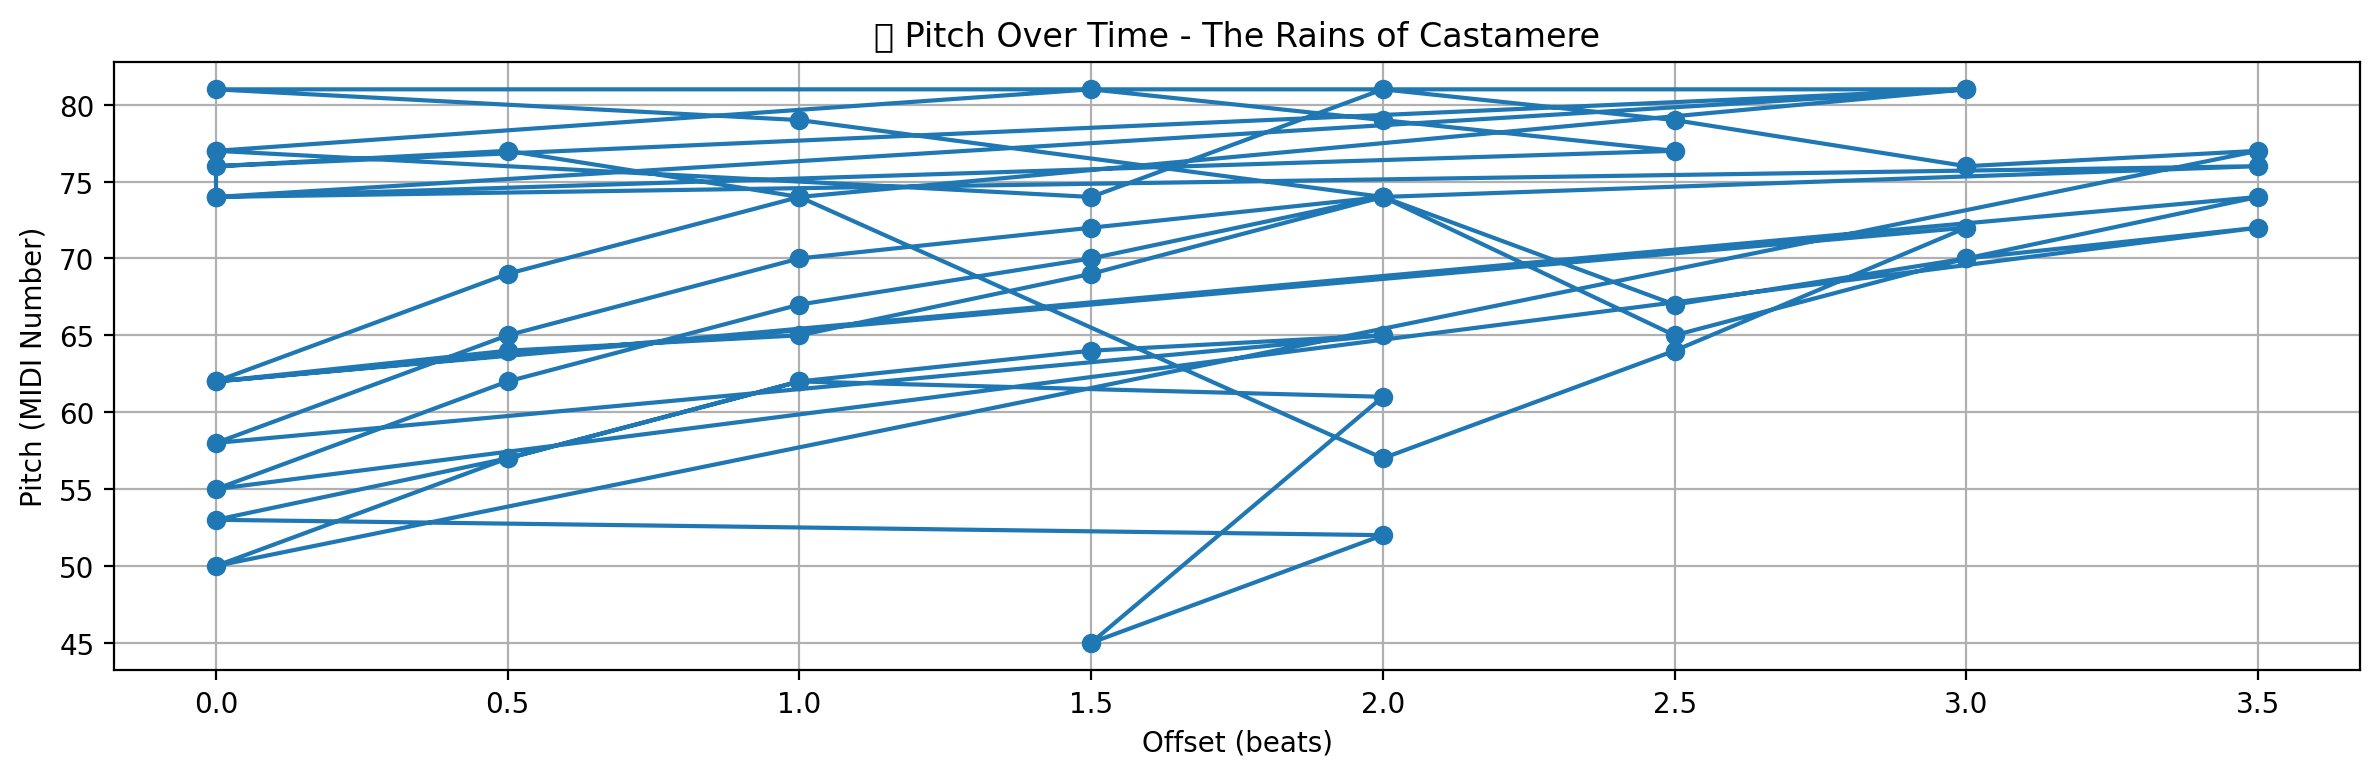

In [11]:
from music21 import converter, note, chord
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取 .mxl 乐谱文件
score = converter.parse('/Users/evelynchu/Desktop/The rains of Castamere.mxl')

# 2. 遍历所有音符和和弦，提取基本信息
rain_music = []
for element in score.recurse():
    if isinstance(element, note.Note):
        rain_music.append({
            'type': 'note',
            'pitch': element.pitch.midi,
            'duration': element.duration.quarterLength,
            'offset': element.offset
        })
    elif isinstance(element, chord.Chord):
        rain_music.append({
            'type': 'chord',
            'pitch': '-'.join(str(n.pitch.midi) for n in element.notes),
            'duration': element.duration.quarterLength,
            'offset': element.offset
        })

# 3. 转为 DataFrame
rain_music_df = pd.DataFrame(rain_music)

# 4. 统一处理音高为数值（单音保持，和弦取平均）
rain_music_df['numeric_pitch'] = rain_music_df['pitch'].apply(
    lambda x: sum([int(p) for p in str(x).split('-')]) / len(str(x).split('-')) if '-' in str(x) else int(x)
)

# 5. 提取基本情感特征
avg_pitch = rain_music_df['numeric_pitch'].mean()
pitch_std = rain_music_df['numeric_pitch'].std()
avg_duration = rain_music_df['duration'].mean()

print(f"🎵 平均音高 (Average Pitch): {avg_pitch:.2f}")
print(f"🎵 音高波动 (Pitch Std Dev): {pitch_std:.2f}")
print(f"🎵 平均音长 (Average Duration): {avg_duration:.2f}")

# 6. 可视化 Pitch 随时间变化（音高趋势图）
plt.figure(figsize=(12, 4))
plt.plot(rain_music_df['offset'], rain_music_df['numeric_pitch'], marker='o')
plt.title("🎼 Pitch Over Time - The Rains of Castamere")
plt.xlabel("Offset (beats)")
plt.ylabel("Pitch (MIDI Number)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# 简单规则函数（你可以调整门槛值）
def estimate_valence_arousal(avg_pitch, pitch_std, avg_duration):
    # valence: 音高越高越快乐，越低越哀伤
    if avg_pitch >= 66:
        valence = 'Positive'
    elif avg_pitch <= 60:
        valence = 'Negative'
    else:
        valence = 'Neutral'

    # arousal: 音高波动大 + 节奏快 → 情绪激烈
    if pitch_std >= 6 and avg_duration <= 1.0:
        arousal = 'High'
    elif pitch_std <= 3 and avg_duration >= 2.0:
        arousal = 'Low'
    else:
        arousal = 'Medium'

    return valence, arousal

# 计算结果
valence_label, arousal_label = estimate_valence_arousal(avg_pitch, pitch_std, avg_duration)

print("🎭 Predicted Emotion Dimensions:")
print(f"Valence (正负情绪): {valence_label}")
print(f"Arousal (情绪激烈度): {arousal_label}")


🎭 Predicted Emotion Dimensions:
Valence (正负情绪): Positive
Arousal (情绪激烈度): High


In [13]:
# 分片（比如每 4 拍一个窗口）
window_size = 4
rain_music_df["window"] = (rain_music_df["offset"] / window_size).astype(int)

# 按窗口统计特征
grouped = rain_music_df.groupby("window").agg({
    "numeric_pitch": ["mean", "std"],
    "duration": "mean"
}).reset_index()

grouped.columns = ['window', 'avg_pitch', 'pitch_std', 'avg_duration']

# 应用情绪映射规则
grouped[["valence", "arousal"]] = grouped.apply(
    lambda row: estimate_valence_arousal(row["avg_pitch"], row["pitch_std"], row["avg_duration"]),
    axis=1, result_type="expand"
)


In [14]:
df_result = pd.DataFrame({
    "text": [...],
    "sentiment_label": [...],
    "confidence": [...]
})


In [15]:
df_result["valence"] = df_result["sentiment_label"].map({
    "POSITIVE": "Positive",
    "NEGATIVE": "Negative"
})


In [16]:
# 确保长度一致（如前100句 vs 前100个乐谱窗口）
min_len = min(len(df_result), len(grouped))
aligned_df = pd.concat([df_result.iloc[:min_len].reset_index(drop=True),
                        grouped.iloc[:min_len][["valence", "arousal"]].reset_index(drop=True)],
                       axis=1)


In [17]:
import seaborn as sns

# 统计一致性
match = (aligned_df["valence_x"] == aligned_df["valence_y"]).sum()
total = len(aligned_df)
print(f"文本-乐谱情绪匹配率: {match}/{total} = {match/total:.2%}")

# 情绪对比热图
sns.heatmap(pd.crosstab(aligned_df["valence_x"], aligned_df["valence_y"]), annot=True)
plt.title("Text vs Music Emotion Valence Alignment")
plt.xlabel("Music Valence")
plt.ylabel("Text Valence")
plt.show()


KeyError: 'valence_x'

In [18]:
print(aligned_df.columns)


Index(['text', 'sentiment_label', 'confidence', 'valence', 'valence',
       'arousal'],
      dtype='object')


In [20]:
# 重命名两个 valence 列
aligned_df.columns = ['text', 'sentiment_label', 'confidence', 'text_valence', 'music_valence', 'music_arousal']

# 匹配分析
match = (aligned_df["text_valence"] == aligned_df["music_valence"]).sum()
total = len(aligned_df)
print(f"文本-乐谱情绪匹配率: {match}/{total} = {match / total:.2%}")


文本-乐谱情绪匹配率: 0/1 = 0.00%
